# 🏦 금융 도메인 실무 프로젝트: 대출 승인 예측을 위한 데이터 분석

## 📋 프로젝트 시나리오

당신은 A은행의 데이터 분석가입니다. 대출 심사팀에서 "어떤 고객 특성이 대출 상환 능력과 관련이 있는지" 분석을 요청했습니다.

목표는 **Phase 0~6 워크플로우**를 따라 데이터를 탐색하고, 주요 변수 간 상관관계를 파악하여 실무 인사이트를 도출하는 것입니다.

## 🎯 분석 목표

- **고객의 소득, 신용점수, 고용형태 등이 대출 승인 여부와 어떤 관계가 있는가?**
- **대출 금액과 상환 기간 사이에 유의미한 패턴이 존재하는가?**
- **어떤 변수가 대출 금리에 가장 큰 영향을 미치는가?**

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한국어 폰트 설정
import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ 환경 세팅 완료")


✅ 환경 세팅 완료


In [45]:
import pandas as pd

# 행(row) 제한을 없애서 모든 데이터 표시 (주의: 너무 많으면 브라우저 느려짐)
# pd.set_option('display.max_rows', None)

# 또는 특정 개수만큼만 보이게 설정 (예: 100행)
pd.set_option('display.max_rows', 100)

# Phase 1. 데이터 생성 및 유형 분류

## 1-1. 가상 데이터셋 생성

실무에서 접할 수 있는 대출 데이터를 시뮬레이션합니다.

In [46]:
# 재현 가능성을 위한 시드 설정
np.random.seed(42)

# 샘플 수
n = 500

# 가상 데이터 생성
df = pd.DataFrame({
    # 명목형
    '성별': np.random.choice(['남성', '여성'], n),
    '고용형태': np.random.choice(['정규직', '계약직', '자영업', '무직'], n, p=[0.5, 0.25, 0.15, 0.1]),
    '주거형태': np.random.choice(['자가', '전세', '월세'], n, p=[0.4, 0.35, 0.25]),
    
    # 순서형
    '신용등급': np.random.choice(['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'C'], n, 
                              p=[0.1, 0.15, 0.2, 0.25, 0.15, 0.1, 0.05]),
    
    # 이산형
    '부양가족수': np.random.poisson(lam=1.5, size=n),
    '연체횟수': np.random.poisson(lam=0.8, size=n),
    
    # 연속형
    '연소득': np.random.lognormal(mean=8.52, sigma=0.5, size=n),  # 만원 단위
    '신용점수': np.random.normal(loc=700, scale=80, size=n),
    '대출금액': np.random.uniform(1000, 10000, size=n),  # 만원
    '대출금리': np.random.uniform(2.5, 8.5, size=n),  # %
    '상환기간': np.random.choice([12, 24, 36, 48, 60], n),  # 개월
})

# 현실성을 위한 조정
df['신용점수'] = df['신용점수'].clip(300, 850)
df['연소득'] = df['연소득'].clip(2000, 15000)
df['부양가족수'] = df['부양가족수'].clip(0, 5)

# 결측치 주입 (현실적 시나리오)
missing_idx = np.random.choice(df.index, size=int(n*0.05), replace=False)
df.loc[missing_idx, '연소득'] = np.nan
missing_idx2 = np.random.choice(df.index, size=int(n*0.03), replace=False)
df.loc[missing_idx2, '신용점수'] = np.nan

# 대출 승인 여부 (종속변수) - 신용점수·소득 기반 확률 모델
approval_prob = 1 / (1 + np.exp(-((df['신용점수'].fillna(df['신용점수'].mean()) - 650) / 100 + 
                                    (df['연소득'].fillna(df['연소득'].mean()) - 6000) / 3000)))
df['대출승인'] = np.random.binomial(1, approval_prob)

print(f"✅ 데이터 생성 완료: {df.shape}")
display(df.head(10))


✅ 데이터 생성 완료: (500, 12)


,성별,고용형태,주거형태,신용등급,부양가족수,연체횟수,연소득,신용점수,대출금액,대출금리,상환기간,대출승인
0,남성,정규직,자가,BB,1,1,4569.13,705.70,1189.08,6.34,12,1
1,여성,정규직,월세,BBB,0,0,5854.70,596.52,1309.88,4.38,36,1
2,남성,자영업,전세,AA,2,0,4874.17,644.34,5012.43,8.25,24,1
3,남성,정규직,자가,AA,2,2,9223.27,626.55,8349.90,2.70,36,0
4,남성,정규직,자가,BBB,2,1,NaN,799.17,8967.15,5.98,48,1
5,여성,계약직,월세,A,0,0,NaN,668.30,1780.36,3.50,48,1
6,남성,무직,전세,AA,1,1,2020.32,785.47,5845.27,6.77,48,0
7,남성,계약직,전세,BBB,2,0,7330.92,748.33,9219.07,3.56,60,1
8,남성,계약직,월세,AAA,1,0,4782.75,850.00,4491.75,3.91,24,1
9,여성,정규직,월세,BBB,5,0,6184.52,581.64,8466.09,5.47,24,1


## 1-2. 데이터 유형 분류

In [47]:
print("=" * 60)
print("■ 전체 구조 파악")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("■ 데이터 유형 분류 결과")
print("=" * 60)

classification = {
    '명목형 (Nominal)': ['성별', '고용형태', '주거형태', '대출승인'],
    '순서형 (Ordinal)': ['신용등급'],
    '이산형 (Discrete)': ['부양가족수', '연체횟수', '상환기간'],
    '연속형 (Continuous)': ['연소득', '신용점수', '대출금액', '대출금리']
}

for category, cols in classification.items():
    print(f"\n{category}:")
    for col in cols:
        print(f"  - {col}")

# 순서형 명시적 인코딩
credit_order = ['C', 'B', 'BB', 'BBB', 'A', 'AA', 'AAA']
df['신용등급'] = pd.Categorical(df['신용등급'], categories=credit_order, ordered=True)

print("\n✅ Phase 1 완료: 유형 분류 및 순서형 인코딩")


■ 전체 구조 파악
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   성별      500 non-null    object 
 1   고용형태    500 non-null    object 
 2   주거형태    500 non-null    object 
 3   신용등급    500 non-null    object 
 4   부양가족수   500 non-null    int32  
 5   연체횟수    500 non-null    int32  
 6   연소득     475 non-null    float64
 7   신용점수    485 non-null    float64
 8   대출금액    500 non-null    float64
 9   대출금리    500 non-null    float64
 10  상환기간    500 non-null    int64  
 11  대출승인    500 non-null    int32  
dtypes: float64(4), int32(3), int64(1), object(4)
memory usage: 41.1+ KB

■ 데이터 유형 분류 결과

명목형 (Nominal):
  - 성별
  - 고용형태
  - 주거형태
  - 대출승인

순서형 (Ordinal):
  - 신용등급

이산형 (Discrete):
  - 부양가족수
  - 연체횟수
  - 상환기간

연속형 (Continuous):
  - 연소득
  - 신용점수
  - 대출금액
  - 대출금리

✅ Phase 1 완료: 유형 분류 및 순서형 인코딩


# Phase 2. 기술통계

## 2-1. 수치형 기술통계

In [48]:
print("=" * 60)
print("■ 수치형 변수 기술통계")
print("=" * 60)

numeric_cols = ['연소득', '신용점수', '대출금액', '대출금리', '부양가족수', '연체횟수']
stats_summary = df[numeric_cols].describe().T

# 추가 지표 계산
stats_summary['range'] = stats_summary['max'] - stats_summary['min']
stats_summary['IQR'] = stats_summary['75%'] - stats_summary['25%']
stats_summary['skew'] = df[numeric_cols].skew()
stats_summary['kurtosis'] = df[numeric_cols].kurtosis()
stats_summary['missing'] = df[numeric_cols].isnull().sum()
stats_summary['missing_pct'] = (df[numeric_cols].isnull().sum() / len(df) * 100).round(2)

display(stats_summary[['mean', 'std', 'min', '50%', 'max', 'skew', 'kurtosis', 'missing_pct']])

print("\n" + "=" * 60)
print("■ 분포 형태 해석")
print("=" * 60)

for col in ['연소득', '신용점수', '대출금액', '대출금리']:
    skew_val = df[col].skew()
    mean_val = df[col].mean()
    median_val = df[col].median()
    
    print(f"\n{col}:")
    print(f"  평균: {mean_val:.2f}, 중앙값: {median_val:.2f}")
    print(f"  왜도: {skew_val:.2f} → ", end="")
    if abs(skew_val) < 0.5:
        print("대칭 분포")
    elif skew_val > 0:
        print("양의 왜도 (오른쪽 꼬리)")
    else:
        print("음의 왜도 (왼쪽 꼬리)")


■ 수치형 변수 기술통계


,mean,std,min,50%,max,skew,kurtosis,missing_pct
연소득,5787.58,3053.46,2000.00,5061.46,15000.00,1.10,0.74,5.00
신용점수,694.53,75.63,472.87,698.22,850.00,-0.14,-0.32,3.00
대출금액,5497.87,2602.07,1055.65,5362.32,9989.14,0.03,-1.17,0.00
대출금리,5.47,1.76,2.52,5.44,8.50,0.06,-1.24,0.00
부양가족수,1.53,1.24,0.00,1.00,5.00,0.76,0.19,0.00
연체횟수,0.76,0.93,0.00,1.00,5.00,1.36,1.95,0.00



■ 분포 형태 해석

연소득:
  평균: 5787.58, 중앙값: 5061.46
  왜도: 1.10 → 양의 왜도 (오른쪽 꼬리)

신용점수:
  평균: 694.53, 중앙값: 698.22
  왜도: -0.14 → 대칭 분포

대출금액:
  평균: 5497.87, 중앙값: 5362.32
  왜도: 0.03 → 대칭 분포

대출금리:
  평균: 5.47, 중앙값: 5.44
  왜도: 0.06 → 대칭 분포


## 2-2. 범주형 기술통계

In [49]:
print("\n" + "=" * 60)
print("■ 범주형 변수 빈도 분석")
print("=" * 60)

categorical_cols = ['성별', '고용형태', '주거형태', '신용등급', '대출승인']

for col in categorical_cols:
    print(f"\n{col} (고유값: {df[col].nunique()})")
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'빈도': freq, '비율(%)': pct.round(2)})
    display(summary)



■ 범주형 변수 빈도 분석

성별 (고유값: 2)


,빈도,비율(%)
성별,,
여성,256,51.20
남성,244,48.80



고용형태 (고유값: 4)


,빈도,비율(%)
고용형태,,
정규직,248,49.60
계약직,125,25.00
자영업,75,15.00
무직,52,10.40



주거형태 (고유값: 3)


,빈도,비율(%)
주거형태,,
자가,196,39.20
전세,170,34.00
월세,134,26.80



신용등급 (고유값: 7)


,빈도,비율(%)
신용등급,,
BBB,137,27.40
A,88,17.60
AA,82,16.40
BB,67,13.40
AAA,54,10.80
B,43,8.60
C,29,5.80



대출승인 (고유값: 2)


,빈도,비율(%)
대출승인,,
1,277,55.40
0,223,44.60


## 2-3. 이상치 및 결측치 처리

In [50]:
print("\n" + "=" * 60)
print("■ 이상치 탐지 (IQR 기반)")
print("=" * 60)

for col in ['연소득', '신용점수', '대출금액', '대출금리']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: 이상치 범위 < {lower:.2f} 또는 > {upper:.2f}")
    print(f"  이상치 수: {len(outliers)} / {len(df)} ({len(outliers)/len(df)*100:.1f}%)")

print("\n" + "=" * 60)
print("■ 결측치 처리")
print("=" * 60)

print(f"연소득 결측: {df['연소득'].isnull().sum()}건 → 중앙값으로 대체")
print(f"신용점수 결측: {df['신용점수'].isnull().sum()}건 → 중앙값으로 대체")

df['연소득'].fillna(df['연소득'].median(), inplace=True)
df['신용점수'].fillna(df['신용점수'].median(), inplace=True)

print("\n✅ Phase 2 완료: 기술통계 및 전처리")



■ 이상치 탐지 (IQR 기반)
연소득: 이상치 범위 < -2103.77 또는 > 12768.65
  이상치 수: 21 / 500 (4.2%)
신용점수: 이상치 범위 < 485.67 또는 > 901.82
  이상치 수: 2 / 500 (0.4%)
대출금액: 이상치 범위 < -3100.34 또는 > 14142.93
  이상치 수: 0 / 500 (0.0%)
대출금리: 이상치 범위 < -0.77 또는 > 11.73
  이상치 수: 0 / 500 (0.0%)

■ 결측치 처리
연소득 결측: 25건 → 중앙값으로 대체
신용점수 결측: 15건 → 중앙값으로 대체

✅ Phase 2 완료: 기술통계 및 전처리


# Phase 3. 시각화

## 3-1. 단변량 시각화 — 수치형

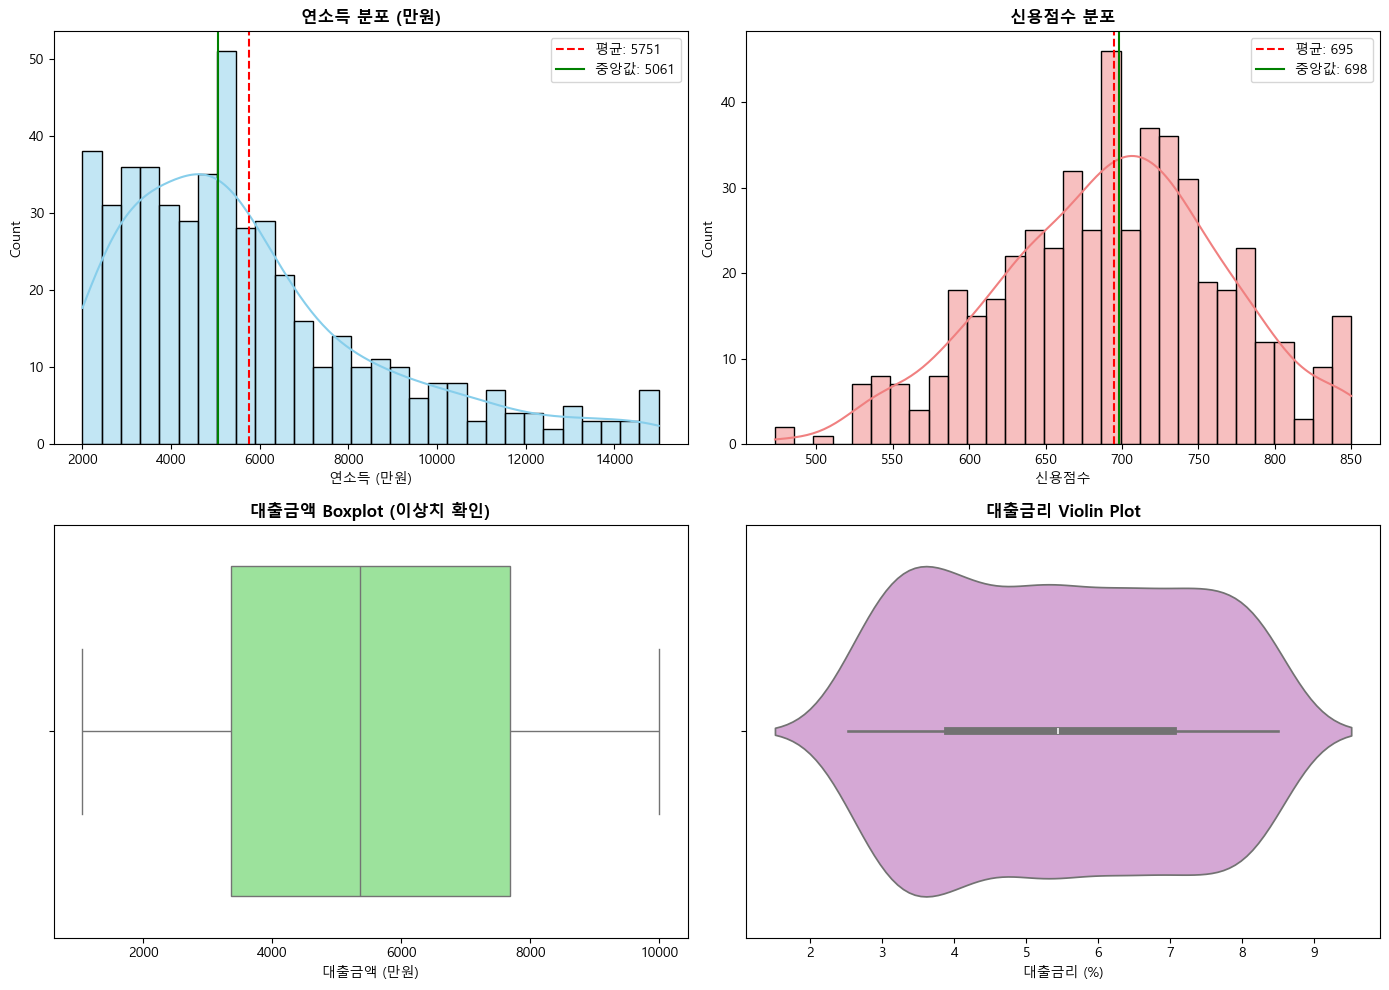

✅ 단변량 시각화 완료


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 연소득 분포
ax = axes[0, 0]
sns.histplot(df['연소득'], kde=True, bins=30, ax=ax, color='skyblue')
ax.axvline(df['연소득'].mean(), color='red', linestyle='--', label=f"평균: {df['연소득'].mean():.0f}")
ax.axvline(df['연소득'].median(), color='green', linestyle='-', label=f"중앙값: {df['연소득'].median():.0f}")
ax.set_title('연소득 분포 (만원)', fontsize=12, weight='bold')
ax.set_xlabel('연소득 (만원)')
ax.legend()

# 신용점수 분포
ax = axes[0, 1]
sns.histplot(df['신용점수'], kde=True, bins=30, ax=ax, color='lightcoral')
ax.axvline(df['신용점수'].mean(), color='red', linestyle='--', label=f"평균: {df['신용점수'].mean():.0f}")
ax.axvline(df['신용점수'].median(), color='green', linestyle='-', label=f"중앙값: {df['신용점수'].median():.0f}")
ax.set_title('신용점수 분포', fontsize=12, weight='bold')
ax.set_xlabel('신용점수')
ax.legend()

# 대출금액 Boxplot
ax = axes[1, 0]
sns.boxplot(x=df['대출금액'], ax=ax, color='lightgreen')
ax.set_title('대출금액 Boxplot (이상치 확인)', fontsize=12, weight='bold')
ax.set_xlabel('대출금액 (만원)')

# 대출금리 Violin Plot
ax = axes[1, 1]
sns.violinplot(x=df['대출금리'], ax=ax, color='plum')
ax.set_title('대출금리 Violin Plot', fontsize=12, weight='bold')
ax.set_xlabel('대출금리 (%)')

plt.tight_layout()
plt.show()

print("✅ 단변량 시각화 완료")


### 위 시각화 그래프에 대한 해석 실습
1. 연소득 분포는 일반적인 소득분포의 경향성을 반영하듯 우측 꼬리가 긴 형태를 보여준다. 일부 고소득자가 평균을 끌어올리고 있는 모습니다.
2. 신용점수의 경우, 크게 경향이 두드러지는 정도는 아니지만, 왼쪽 꼬리가 긴 형태를 보여준다. 
신용등급이 특히 낮은 인원들이 일부 포진한 모습을 볼 수 있다.
3. 대출금액의 경우, 5000만원 중후반대에 중앙값이 형성되며, 상위 구간 박스가 더 큰 것을 볼 수 있다. 하지만 그 정도가 크지 않다.
4. 대출 금리의 경우, 3%~3.5% 구간에 가장 많이 포진해 있으며, 양 극단값으로 갈 수록 급격히 줄어든다. 저금리 혜택을 받는 인원이 타 구간에 비해 상대적으로 많긴 하지만, 그 정도가 매우 크게 나타나지는 않는다.

### 해석에 대한 AI Feedback
제시해주신 해석은 전반적으로 시각화 차트의 분포 형태(Skewness), 중심 경향성(Central Tendency), 데이터의 치우침을 아주 정확하게 짚어내셨습니다. 훌륭합니다!

전문성을 한 스푼 더할 수 있도록, 각 항목별로 수치적 근거를 보완하거나 도메인 관점의 인사이트를 더할 수 있는 팁을 드립니다.

📊 상세 검토 및 보완 제안
1. 연소득 분포
- 사용자 해석: "일반적인 소득분포의 경향성을 반영하듯 우측 꼬리가 긴 형태를 보여준다. 일부 고소득자가 평균을 끌어올리고 있는 모습니다."  
✅ 검토: 아주 정확한 해석입니다. 소득 데이터는 전형적으로 Positive Skew(오른쪽 꼬리 분포) 형태를 띱니다.  
💡 보완 팁: 평균과 중앙값의 차이를 구체적인 수치로 언급하면 주장에 힘이 실립니다.  
예: "평균(5,751만원)이 중앙값(5,061만원)보다 약 700만원 가량 높게 형성된 것은 우측 꼬리에 위치한 고소득층의 영향임을 알 수 있습니다."    

1. 신용점수 분포  
- 사용자 해석: "크게 경향이 두드러지는 정도는 아니지만, 왼쪽 꼬리가 긴 형태를 보여준다. 신용등급이 특히 낮은 인원들이 일부 포진한 모습을 볼 수 있다."  
✅ 검토: 히스토그램의 형태와 정규분포 곡선(붉은 선)의 차이를 잘 포착하셨습니다. 이는 **Negative Skew(왼쪽 꼬리 분포)**의 전형적인 모습입니다.  
💡 보완 팁: 금융권에서는 이를 **'잠재적 리스크 군'**으로 해석하기도 합니다.  
예: "전반적으로 고신용자에 집중되어 안정적인 분포를 보이나, 왼쪽 꼬리로 길게 늘어진 500점대 이하 저신용 구간은 향후 연체 리스크 관리가 필요한 그룹으로 판단됩니다."    

1. 대출금액 (Boxplot)  
- 사용자 해석: "5000만원 중후반대에 중앙값이 형성되며, 상위 구간 박스가 더 큰 것을 볼 수 있다. 하지만 그 정도가 크지 않다."  
✅ 검토: 박스(Interquartile Range)의 대칭성과 중앙값 위치를 잘 보셨습니다.  
💡 보완 팁: **'데이터의 퍼짐 정도'**와 **'이상치 유무'**를 함께 언급해 보세요.  
예: "중앙값은 약 5,300만원 부근이며, 박스 좌우 수염(Whisker) 내에 모든 데이터가 포함되어 있어, 특이하게 튀는 초고액/초소액 대출 건(이상치)은 없는 안정적인 데이터셋입니다."  
1. 대출금리 (Violin Plot)  
- 사용자 해석: "3%~3.5% 구간에 가장 많이 포진해 있으며, 양 극단값으로 갈 수록 급격히 줄어든다. 저금리 혜택을 받는 인원이... 상대적으로 많다."  
✅ 검토: 바이올린 플롯의 너비(밀도)를 통해 최빈 구간(Mode)을 잘 찾으셨습니다.  
💡 보완 팁: **'차주의 건전성'**과 연결 지을 수 있습니다.  
예: "3% 대의 저금리 구간이 가장 두터운(Fat) 항아리 형태를 띠고 있습니다. 이는 해당 포트폴리오가 고금리 대출보다는 우량 차주 위주로 구성되어 있음을 시사합니다."  

📝 총평  
작성하신 내용은 현상을 있는 그대로 잘 설명("Descriptive Analysis")하고 있습니다. 여기에 위에서 말씀드린 **"그래서 이 데이터가 비즈니스적으로 어떤 의미인가?(Insight)"**를 한 문장씩만 덧붙이시면 완벽한 분석 보고서가 될 것입니다.

  다음 단계로 넘어가서, 이 변수들이 실제 **Target(대출승인 여부)**과 어떤 관계가 있는지 분석해 볼까요?

## 3-2. 단변량 시각화 — 범주형

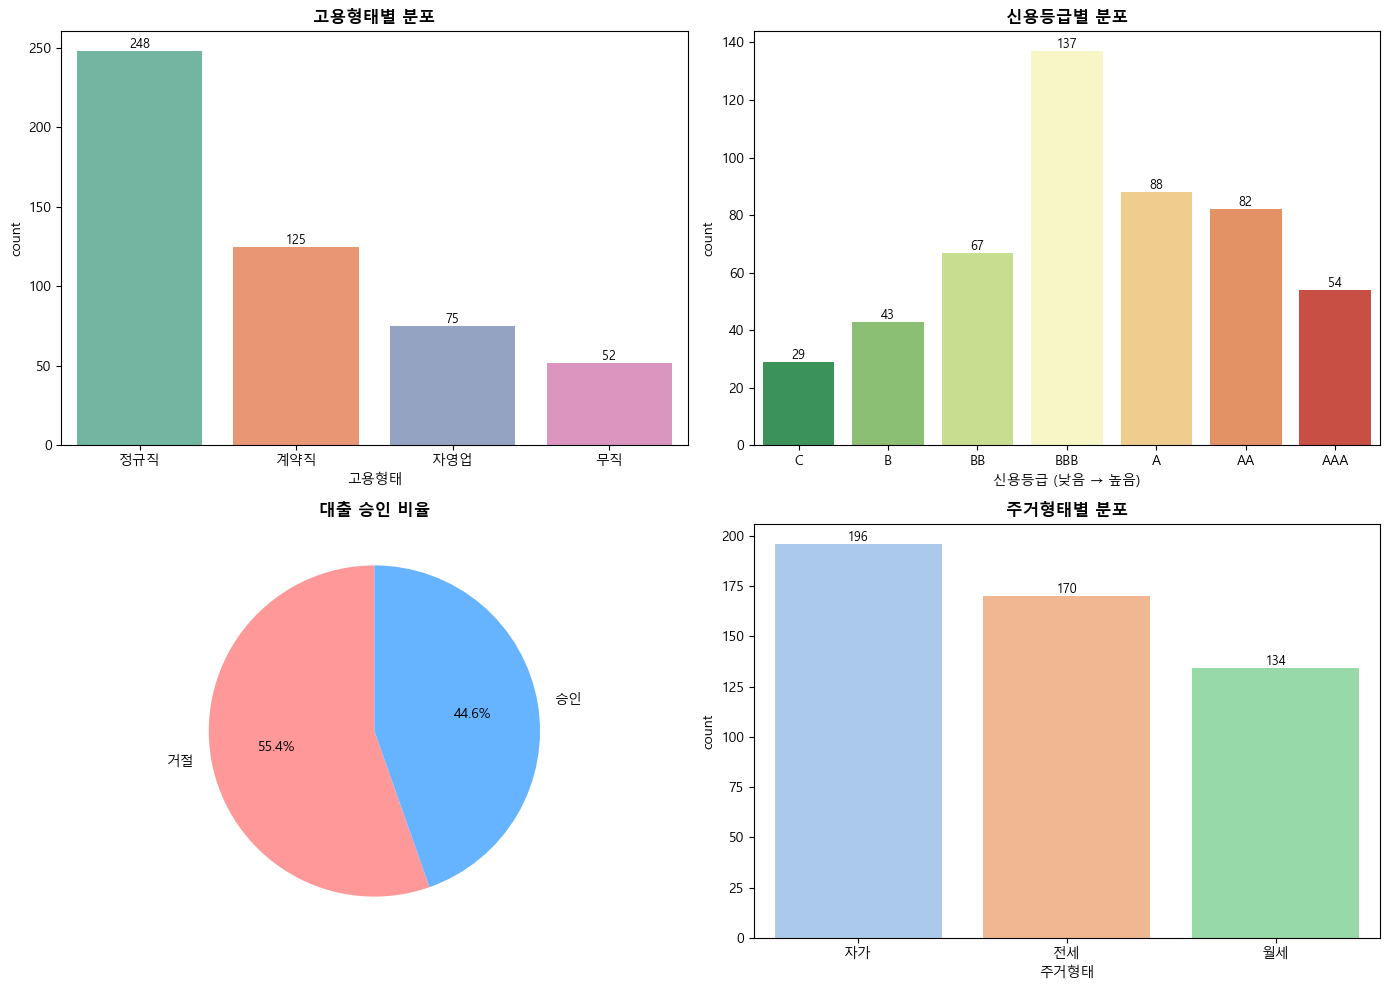

✅ 범주형 시각화 완료


In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 고용형태
ax = axes[0, 0]
order = df['고용형태'].value_counts().index
sns.countplot(data=df, x='고용형태', order=order, ax=ax, palette='Set2')
ax.set_title('고용형태별 분포', fontsize=12, weight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

# 신용등급
ax = axes[0, 1]
sns.countplot(data=df, x='신용등급', order=credit_order, ax=ax, palette='RdYlGn_r')
ax.set_title('신용등급별 분포', fontsize=12, weight='bold')
ax.set_xlabel('신용등급 (낮음 → 높음)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

# 대출승인 비율
ax = axes[1, 0]
approval_counts = df['대출승인'].value_counts()
colors = ['#ff9999', '#66b3ff']
ax.pie(approval_counts, labels=['거절', '승인'], autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title('대출 승인 비율', fontsize=12, weight='bold')

# 주거형태
ax = axes[1, 1]
order = df['주거형태'].value_counts().index
sns.countplot(data=df, x='주거형태', order=order, ax=ax, palette='pastel')
ax.set_title('주거형태별 분포', fontsize=12, weight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ 범주형 시각화 완료")


### 시각화 해석 연습
1. 정규직이 가장 많고, 계약직, 자영업, 무직이 그 뒤를 잇는다. 정규직이 나머지 모두를 합친 만큼의 숫자를 보여주고 있다.
   1. 상대적으로 안정적인 수입을 가질 것으로 예상되는 정규직을 대상으로, 수익 안정성에 대한 지표를 뽑아보면 좋을 것 같다.
   2. 상대적으로 안정적인 수익 지표를 보여준다면 정규직을 대상으로 한 대출상품을 개발해도 좋을 것이다.
2. 신용등급 분포 역시 신용점수와 마찬가지로 약한 음의왜도를 보여주고 있다. 저신용자들에 대한 일정 수준의 관리가 필요할 것이다.
   1. 신용등급 BBB를 기준으로 양측을 나눠보았을 때, 고신용자의 숫자가 더 많지만, 그럼에도 대출 승인 비율이 거절이 더 많은 것이 확인된다.
3. 대출 거절이 더 많은 이유를 찾아봐야 할 것이다.
   1. 고용형태별 대출 승인도 알아보면 좋을 것 같다.
4. 주거형태별 분포를 봤을때, 자가 비율이 높지만 전세, 월세 간 차이가 크진 않은 것으로 보인다.
   1. 자가의 경우 주택담보대출이 가능할 것이다!

5. 고용형태 별 대출 승인 비율도 나타내면 좋을 것 같다
6. 고용형태 별 신용등급 비율도 수익 안정성과 더불어 좋은 지표가 될 수 있을 것 같다. -> 대출상품 개발의 근거

### 해석에 대한 AI Feedback (Phase 3-2)
사용자께서 범주형 변수의 특성과 비즈니스적 연결 고리를 아주 잘 찾아내셨습니다. 특히 **정규직 비중**과 **주거 형태(자가)**를 대출 상품 설계와 연결한 점은 실무적인 인사이트가 돋보입니다.

💡 **추가 고려사항:**
1. **신용등급과 실제 승인율의 괴리:** 2번 해석에서 언급하신 '고신용자임에도 거절이 많은 이유'는 매우 중요한 분석 포인트입니다. 이는 소득 대비 부채 비율(DTI)이나 기존 대출 건수가 영향을 미쳤을 가능성이 높으므로, 이변량 분석에서 이를 검증해볼 필요가 있습니다.
2. **고용 형태의 질적 차이:** 단순히 숫자가 많은 것뿐만 아니라, 자영업자나 계약직 군에서의 승인율이 유독 낮은지를 확인하여 포용적 금융 관점에서의 틈새 시장을 발굴할 수 있습니다.
3. **주거 형태의 담보 가치:** 자가 거주자의 경우 대출 금액(Amount) 자체가 다른 군보다 유의미하게 높은지 확인하면 '우량 고객군' 정의에 도움이 될 것입니다.

## 3-3. 이변량 시각화 — 수치형 × 수치형

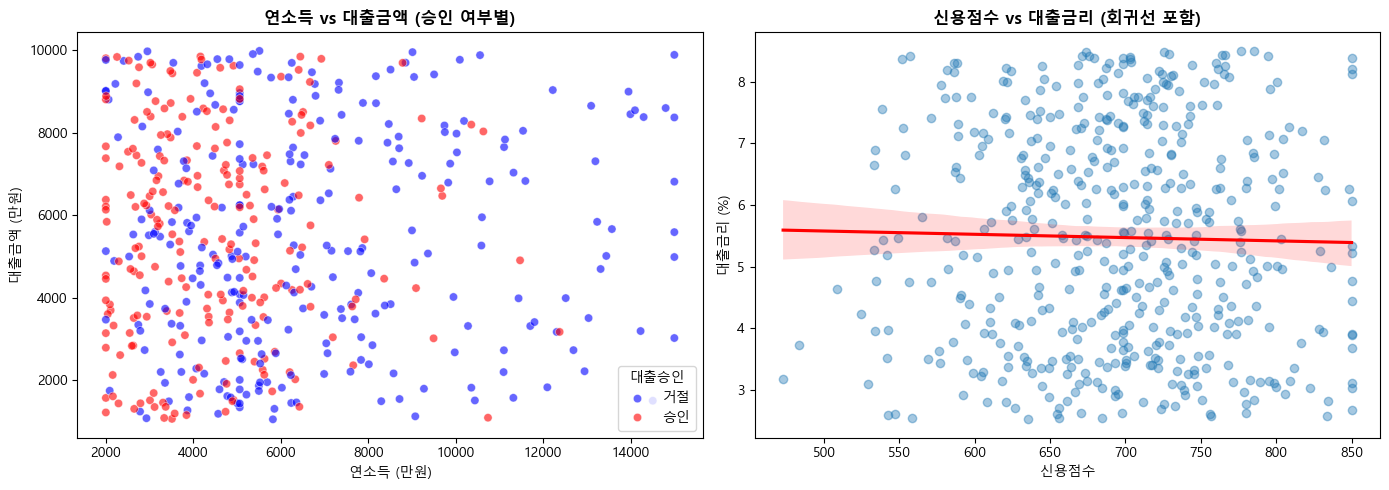

✅ 이변량 시각화 완료


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 연소득 vs 대출금액
ax = axes[0]
sns.scatterplot(data=df, x='연소득', y='대출금액', hue='대출승인', 
                palette={0: 'red', 1: 'blue'}, alpha=0.6, ax=ax)
ax.set_title('연소득 vs 대출금액 (승인 여부별)', fontsize=12, weight='bold')
ax.set_xlabel('연소득 (만원)')
ax.set_ylabel('대출금액 (만원)')
ax.legend(title='대출승인', labels=['거절', '승인'])

# 신용점수 vs 대출금리
ax = axes[1]
sns.regplot(data=df, x='신용점수', y='대출금리', scatter_kws={'alpha': 0.4}, 
            line_kws={'color': 'red'}, ax=ax)
ax.set_title('신용점수 vs 대출금리 (회귀선 포함)', fontsize=12, weight='bold')
ax.set_xlabel('신용점수')
ax.set_ylabel('대출금리 (%)')

plt.tight_layout()
plt.show()

print("✅ 이변량 시각화 완료")


1. 연소득 vs 대출금액 (승인 여부별)
   1. 고소득층에 대출 거절이 몰려있는 것으로 보인다.
   2. 소득이 낮을 수록 대출 신청 건수가 많은 것으로 보인다.
   3. 고소득자의 거절 비율이 높은 이유를 찾아봐야 할 것 같다.
2. 신용점수 vs 대출금리 (회귀선 포함)
   1. 신용점수와 대출금리는 크게 관련이 없는 것으로 보인다.
   2. 대출금리 별로 분포가 많이 달라지지 않는 것 같다.
   3. 회귀선에 대해서는 어떻게 해석해야할 지 잘 모르겠다.

## 3-4. 이변량 시각화 — 범주형 × 수치형

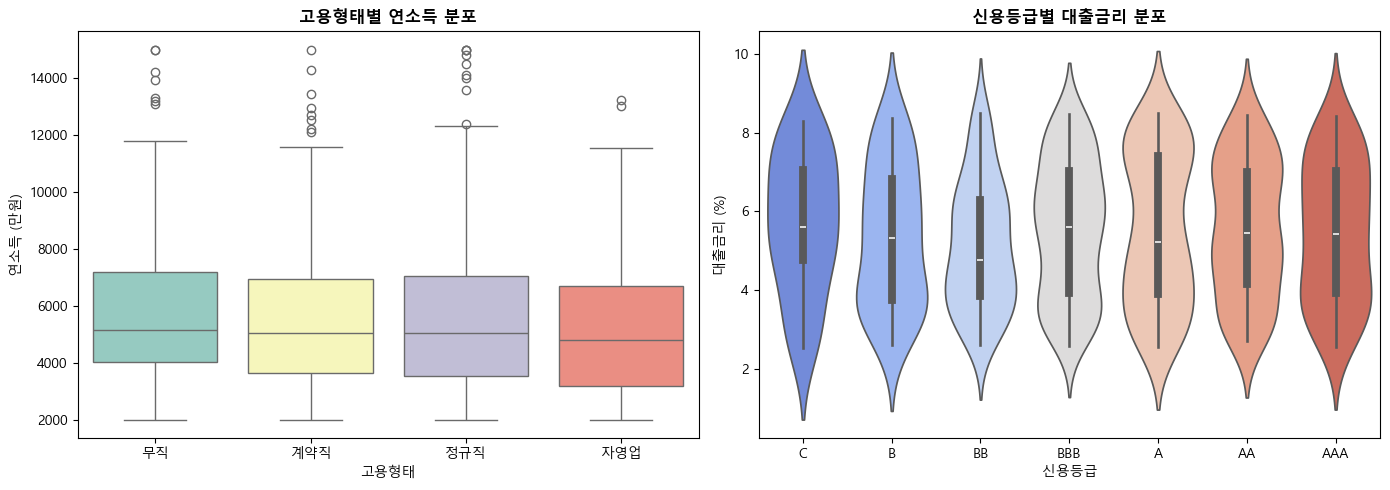

✅ 범주형×수치형 시각화 완료


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 고용형태별 연소득 분포
ax = axes[0]
employment_order = df.groupby('고용형태')['연소득'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='고용형태', y='연소득', order=employment_order, ax=ax, palette='Set3')
ax.set_title('고용형태별 연소득 분포', fontsize=12, weight='bold')
ax.set_xlabel('고용형태')
ax.set_ylabel('연소득 (만원)')

# 신용등급별 대출금리
ax = axes[1]
sns.violinplot(data=df, x='신용등급', y='대출금리', order=credit_order, ax=ax, palette='coolwarm')
ax.set_title('신용등급별 대출금리 분포', fontsize=12, weight='bold')
ax.set_xlabel('신용등급')
ax.set_ylabel('대출금리 (%)')

plt.tight_layout()
plt.show()

print("✅ 범주형×수치형 시각화 완료")


## 3-5. 상관관계 히트맵

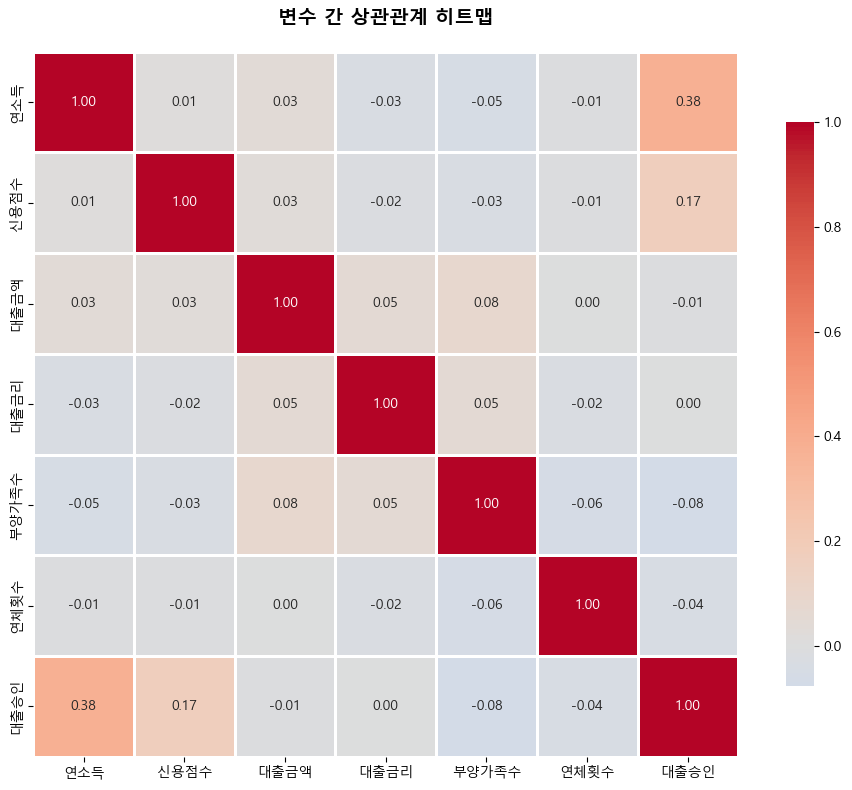

✅ Phase 3 완료: 시각화


In [55]:
plt.figure(figsize=(10, 8))

numeric_cols_corr = ['연소득', '신용점수', '대출금액', '대출금리', '부양가족수', '연체횟수', '대출승인']
corr_matrix = df[numeric_cols_corr].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('변수 간 상관관계 히트맵', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✅ Phase 3 완료: 시각화")


# Phase 4. 가설검정 및 가정 점검

## 4-1. 정규성 검정 (Shapiro-Wilk Test)

In [56]:
print("=" * 60)
print("■ 정규성 검정 (Shapiro-Wilk)")
print("=" * 60)

for col in ['연소득', '신용점수', '대출금액', '대출금리']:
    stat, p_value = stats.shapiro(df[col].dropna())
    print(f"\n{col}:")
    print(f"  통계량: {stat:.4f}, p-value: {p_value:.4f}")
    if p_value > 0.05:
        print(f"  → 정규분포를 따른다 (p > 0.05)")
    else:
        print(f"  → 정규분포를 따르지 않는다 (p ≤ 0.05)")

print("\n💡 해석: 대부분의 금융 데이터는 정규분포를 따르지 않으므로,")
print("   비모수 검정(Spearman) 또는 로그 변환을 고려해야 합니다.")


■ 정규성 검정 (Shapiro-Wilk)

연소득:
  통계량: 0.8995, p-value: 0.0000
  → 정규분포를 따르지 않는다 (p ≤ 0.05)

신용점수:
  통계량: 0.9929, p-value: 0.0189
  → 정규분포를 따르지 않는다 (p ≤ 0.05)

대출금액:
  통계량: 0.9553, p-value: 0.0000
  → 정규분포를 따르지 않는다 (p ≤ 0.05)

대출금리:
  통계량: 0.9488, p-value: 0.0000
  → 정규분포를 따르지 않는다 (p ≤ 0.05)

💡 해석: 대부분의 금융 데이터는 정규분포를 따르지 않으므로,
   비모수 검정(Spearman) 또는 로그 변환을 고려해야 합니다.


## 4-2. 등분산 검정 (Levene's Test)

In [57]:
print("\n" + "=" * 60)
print("■ 등분산 검정: 고용형태별 연소득")
print("=" * 60)

groups = [df[df['고용형태'] == cat]['연소득'].dropna() 
          for cat in df['고용형태'].unique()]
stat, p_value = stats.levene(*groups)

print(f"Levene 통계량: {stat:.4f}, p-value: {p_value:.4f}")
if p_value > 0.05:
    print("→ 등분산 가정이 충족됨 (p > 0.05)")
else:
    print("→ 등분산 가정이 위배됨 (p ≤ 0.05) → Welch ANOVA 사용 권장")

print("\n✅ Phase 4 완료: 가정 점검")



■ 등분산 검정: 고용형태별 연소득
Levene 통계량: 0.9655, p-value: 0.4087
→ 등분산 가정이 충족됨 (p > 0.05)

✅ Phase 4 완료: 가정 점검


# Phase 5. 상관 분석

## 5-1. Pearson 상관계수

In [58]:
print("=" * 60)
print("■ Pearson 상관분석 (주요 변수)")
print("=" * 60)

pairs = [
    ('연소득', '대출금액'),
    ('신용점수', '대출금리'),
    ('연체횟수', '대출금리'),
]

for var1, var2 in pairs:
    r, p = stats.pearsonr(df[var1].dropna(), df[var2].dropna())
    print(f"\n{var1} ↔ {var2}:")
    print(f"  Pearson r = {r:.4f}, p-value = {p:.4f}")
    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "n.s."
    print(f"  유의성: {sig}")
    
    if abs(r) < 0.3:
        strength = "약한"
    elif abs(r) < 0.7:
        strength = "중간"
    else:
        strength = "강한"
    direction = "양의" if r > 0 else "음의"
    print(f"  → {strength} {direction} 상관관계")


■ Pearson 상관분석 (주요 변수)

연소득 ↔ 대출금액:
  Pearson r = 0.0346, p-value = 0.4403
  유의성: n.s.
  → 약한 양의 상관관계

신용점수 ↔ 대출금리:
  Pearson r = -0.0226, p-value = 0.6149
  유의성: n.s.
  → 약한 음의 상관관계

연체횟수 ↔ 대출금리:
  Pearson r = -0.0245, p-value = 0.5844
  유의성: n.s.
  → 약한 음의 상관관계


## 5-2. Spearman 순위 상관계수

In [59]:
print("\n" + "=" * 60)
print("■ Spearman 상관분석 (비정규 분포 대응)")
print("=" * 60)

for var1, var2 in pairs:
    rho, p = stats.spearmanr(df[var1].dropna(), df[var2].dropna())
    print(f"\n{var1} ↔ {var2}:")
    print(f"  Spearman ρ = {rho:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print(f"  → 유의미한 순위 상관관계 존재")
    else:
        print(f"  → 유의미한 순위 상관관계 없음")



■ Spearman 상관분석 (비정규 분포 대응)

연소득 ↔ 대출금액:
  Spearman ρ = 0.0210, p-value = 0.6389
  → 유의미한 순위 상관관계 없음

신용점수 ↔ 대출금리:
  Spearman ρ = -0.0297, p-value = 0.5071
  → 유의미한 순위 상관관계 없음

연체횟수 ↔ 대출금리:
  Spearman ρ = -0.0396, p-value = 0.3766
  → 유의미한 순위 상관관계 없음


## 5-3. 카이제곱 검정 (범주형 × 범주형)

In [60]:
print("\n" + "=" * 60)
print("■ χ² 독립성 검정: 고용형태 × 대출승인")
print("=" * 60)

contingency_table = pd.crosstab(df['고용형태'], df['대출승인'])
print("\n교차표:")
print(contingency_table)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nχ² = {chi2:.4f}, p-value = {p:.4f}, 자유도 = {dof}")

if p < 0.05:
    print("→ 고용형태와 대출승인은 독립적이지 않다 (유의미한 관계 존재)")
else:
    print("→ 고용형태와 대출승인은 독립적이다 (관계 없음)")

# Cramér's V (효과 크기)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V = {cramers_v:.4f} (효과 크기)")

print("\n✅ Phase 5 완료: 상관 분석")



■ χ² 독립성 검정: 고용형태 × 대출승인

교차표:
대출승인    0    1
고용형태          
계약직    54   71
무직     24   28
자영업    36   39
정규직   109  139

χ² = 0.5431, p-value = 0.9093, 자유도 = 3
→ 고용형태와 대출승인은 독립적이다 (관계 없음)
Cramér's V = 0.0330 (효과 크기)

✅ Phase 5 완료: 상관 분석
